# DE EIA - Réseaux de neurones

2025-26 - Bordeaux INP - ENSEIRB-MATMECA

Michaël Clément

## TP3 - Réseaux de neurones convolutionnels (CNN)

Dans ce TP, nous allons manipuler les réseaux de neurones convolutionels (CNN) utilisés pour les images.
Nous commencerons par appliquer manuellement des filtres de convolution pour en comprendre le fonctionnement, avant de construire et entraîner un premier CNN pour la classification d'images.
Nous allons étudier l'architecture du réseau, mesurer son nombre de paramètres, analyser les performances et observer les effets de l'entraînement sur GPU.

In [3]:
import torch
import torch.nn as nn
import torchvision
import skimage
import numpy as np
import matplotlib.pyplot as plt

## 1. Filtres de convolution classiques en traitement d'images

Nous allons d'abord appliquer quelques filtres de convolution classique sur des images d'exemple. Il n'y a pas d'apprentissage ou de réseaux de neurones ici, il s'agit d'opérations élémentaires de traitement d'images (détection de contours, flou, etc.).

im1.shape=(300, 451, 3)
im2.shape=(400, 600, 3)


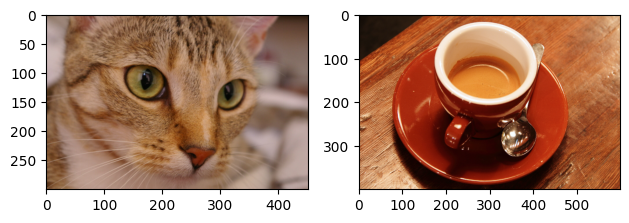

In [4]:
# Deux images de test
im1 = skimage.data.chelsea()
im2 = skimage.data.coffee()
print(f'{im1.shape=}')
print(f'{im2.shape=}')

plt.subplot(121); plt.imshow(im1)
plt.subplot(122); plt.imshow(im2)
plt.tight_layout()

Exemples de filtres de convolution en traitement d'images :

In [5]:
# Détection de contours horizontaux
sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

# Détection de contours verticaux
sobel_y = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
], dtype=np.float32)

# Flou (filtre moyenneur)
blur = np.array([
    [1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1]
], dtype=np.float32) / 25.0

Fonction pour réaliser une convolution 2D manuellement :

In [6]:
def convolve2d(image, kernel):
    kh, kw = kernel.shape
    ih, iw = image.shape
    # Image de sortie plus petite
    out_h = ih - kh + 1
    out_w = iw - kw + 1
    output = np.zeros((out_h, out_w), dtype=np.float32)
    # Pour chaque pixel de l'image de sortie
    for i in range(out_h):
        for j in range(out_w):
            # Récupérer la zone correspondante dans l'image d'entrée
            # et multiplier avec le filtre de convolution
            region = image[i:i+kh, j:j+kw]
            output[i, j] = np.sum(region * kernel)
    
    return output

Exemples d'applications de filtres sur les images de test :

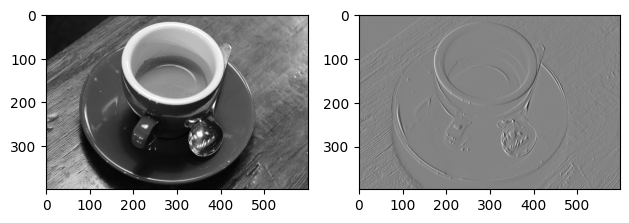

In [7]:
# On convertit l'image en niveaux de gris en moyennant les canaux de couleurs
im = im2.mean(axis=2)

# Application de la convolution 2D
out = convolve2d(im, sobel_x)


# Affichage du résultat
plt.subplot(121); plt.imshow(im, cmap='gray')
plt.subplot(122); plt.imshow(out, cmap='gray')
plt.tight_layout()

## 2. CNN pour la classification d'images

Nous allons maintenant mettre en place un réseau de neurones convolutionnel (CNN) pour la classification d'images sur le dataset MNIST.

Dans les CNN, les filtres de convolutions sont des paramètres du modèle : ils sont initialisés aléatoirement et c'est l'entraînement qui va ajuster les valeurs des filtres afin de réaliser la tâche de classification.
Les filtres servent donc à extraire des caractéristiques (*features*) des images qui vont aider à la classification.

### Dataset

Charger le dataset MNIST en vous inspirant du TP précédent. Cette fois, nous allons garder les images au format 2D.

In [8]:
import torchvision
from torch.utils.data import TensorDataset, DataLoader

# Au chargement les X seront au format (N, H, W) où N est le nombres d'images et H, W la taille des images.
# En PyTorch il faut un format (N, C, H, W) où C est le nombre de canaux (C=3 pour RGB, C=1 pour niveaux de gris)
# Il faudra donc ajouter la dimension C avec C=1 pour les données de MNIST

# YOUR CODE HERE
raise NotImplementedError()

NotImplementedError: 

### Architecture CNN

Mettre en place une architecture CNN similaire au réseau LeNet-5 pour la classification MNIST (10 classes).
Le réseau doit contenir :
- une partie convolutionnelle (enchaînement de couches Conv2D et MaxPool2D)
- une partie classification (MLP classique)

Ne pas oublier d'utiliser des fonctions d'activation non linéaires (Sigmoid, ReLU) dans le réseau.

In [ ]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        # YOUR CODE HERE
        raise NotImplementedError()

    def forward(self, x):
        # YOUR CODE HERE
        raise NotImplementedError()

Calculer à la main le nombre de paramètres de votre réseau de neurones, ainsi que les tailles des représentations intermédiaires dans le réseau (*feature maps* pour la partie convolutionnelle, vecteurs d'activation pour la partie MLP). Vérifier les calculs en inspectant le réseau avec PyTorch.

In [ ]:
# YOUR CODE HERE
raise NotImplementedError()

## 3. Entraînement du CNN sur GPU

Pour utiliser le GPU avec PyTorch, il faut déplacer le modèle et les données sur le GPU à l'aide de `.to(device)` :

In [ ]:
# Choix du matériel (GPU ou CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"device = {device}")

# Instanciation du modèle et passage sur le device
model = CNN().to(device)

for X_batch, y_batch in train_dataloader:
    # Passage des données sur le device
    X_batch = X_batch.to(device)
    y_batch = y_batch.to(device)
    # Forward pass
    y_pred = model(X_batch)
    print(f'Batch traité sur {X_batch.device}')
    break

Mettre en place la boucle d'apprentissage pour entraîner le CNN. Monitorer la loss sur les ensembles de train et de test au fil des epochs.

In [ ]:
model = CNN().to(device)

n_epochs = 10
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)

def train_epoch(model, dataloader, loss_fn, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = total = 0
    for X, y in dataloader:
        # Passage des données dans le modèle et optimisation des paramètres
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        loss.backward()
        optimizer.step()
        # Monitoring de la loss et de l'accuracy
        running_loss += loss.item() * X_batch.size(0)
        correct += (y_pred.argmax(dim=1) == y).sum().item()
        total += y.size(0)
    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_accuracy = correct / total
    return epoch_loss, epoch_accuracy

def eval_epoch(model, dataloader, device):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for X, y in dataloader:
            # Passage des données dans le modèle et évaluation de l'accuracy
            X, y = X.to(device), y.to(device)
            y_pred = model(X).argmax(dim=1)
            correct += (y_pred == y).sum().item()
            total += y.size(0)
    accuracy = correct / total
    return accuracy

for epoch in range(n_epochs):
    train_loss, train_acc = train_epoch(model, train_dataloader, loss_fn, optimizer, device)
    test_acc = eval_epoch(model, test_dataloader, device)

    print(f"Epoch {epoch+1}/{n_epochs} - "
          f"Train Loss: {train_loss:.4f} - "
          f"Train Acc: {train_acc*100:.2f}% - "
          f"Test Acc: {test_acc*100:.2f}%")

## 4. Finetuning d'un CNN pré-entraîné

`torchvision` met à disposition de nombreux CNN déjà entraînés pour la classification d'images (par exemple sur ImageNet : 1.2 millions d'images, 1000 classes).
Il est courant de réutiliser ces modèles pour les spécialiser (*finetuning*) sur des tâches spécifiques, en particulier lorsque l'on dispose de peu de données d'entraînement.
Pour cela, on conserve généralement la partie convolutionnelle et on remplace la tête de classification par un modèle adapté à notre tâche.
Seule cette nouvelle partie est entraînée dans un premier temps, et éventuellement l'ensemble du modèle dans un second temps si on souhaite vraiment affiner le modèle.

### Dataset Oxford Flowers 102

Pour illustrer cette idée, nous allons utiliser le dataset Oxford Flowers 102, composé de 1020 images réparties en 102 classes de fleurs.

In [ ]:
# Chargement du dataset Oxford Flowers 102
flowers_dataset = torchvision.datasets.Flowers102(root='./data', split='train', download=True)

# Affichage de quelques images
plt.figure(figsize=(12,6))
indices = torch.randint(0, len(flowers_dataset), (6,))  # 6 indices aléatoires
for i, idx in enumerate(indices):
    img, label = flowers_dataset[idx.item()]
    plt.subplot(1, 6, i+1)
    plt.imshow(img)
    plt.title(f"Class {label}")
    plt.axis('off')
plt.tight_layout()

### Chargement d'un modèle pré-entraîné

Nous allons utiliser le réseau ResNet18.

In [ ]:
from torchvision import models

# Chargement du modèle ResNet18 pré-entraîné et gel des paramètres
resnet_finetuning = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
for param in resnet_finetuning.parameters():
    param.requires_grad = False

# Remplacer la dernière couche fc pour avoir 102 classes
num_features = resnet_finetuning.fc.in_features
resnet_finetuning.fc = nn.Sequential(
    nn.Linear(num_features, 128),
    nn.ReLU(),
    nn.Linear(128, 102),
)

# Passage sur GPU
resnet_finetuning = resnet_finetuning.to(device)

### Préparation des données

Lorsque l'on utilise un modèle pré-entraîné, il faut généralement modifier nos données afin qu'elles soient conformes au format qui a été utilisé pour entraîner ce modèle préalablement.
En l'occurrence, le réseau ResNet18 a été entraîné sur des images de taille 224x224 et selon une normalisation spécifique au dataset ImageNet.
Afin d'appliquer ce format, il est possible d'utiliser les `transforms` en PyTorch.

In [ ]:
from torchvision import transforms

# Définition des transformations adaptées au ResNet pré-entraîné (224x224, normalisation ImageNet)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],  # ImageNet mean
        std=[0.229, 0.224, 0.225]    # ImageNet std
    )
])

# Chargement du dataset Oxford Flowers 102
train_dataset = torchvision.datasets.Flowers102(root='./data', split='train', download=True, transform=transform)
valid_dataset = torchvision.datasets.Flowers102(root='./data', split='val', download=True, transform=transform)

# Création des DataLoaders
batch_size = 128
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

### Finetuning

In [ ]:
# Seuls les paramètres de la dernière couche seront optimisés
optimizer = torch.optim.Adam(resnet_finetuning.fc.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

# Lancement du finetuning
train_accs_resnet = []
test_accs_resnet = []
for epoch in range(n_epochs):
    train_loss, train_acc = train_epoch(resnet_finetuning, train_dataloader, loss_fn, optimizer, device)
    test_acc = eval_epoch(resnet_finetuning, valid_dataloader, device)

    train_accs_resnet.append(train_acc)
    test_accs_resnet.append(test_acc)
    print(f"Epoch {epoch+1}/{n_epochs} - "
          f"Train Loss: {train_loss:.4f} - "
          f"Train Acc: {train_acc*100:.2f}% - "
          f"Test Acc: {test_acc*100:.2f}%")

Comparaison avec un CNN baseline entraîné depuis le départ :

In [ ]:
baseline_cnn = nn.Sequential(
    nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(),
    nn.MaxPool2d(2, 2),
    nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
    nn.MaxPool2d(2, 2),
    nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
    nn.MaxPool2d(2, 2),
    nn.Flatten(),
    nn.Linear(128 * 28 * 28, 256), nn.ReLU(),
    nn.Linear(256, 102)
).to(device)


optimizer = torch.optim.Adam(baseline_cnn.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

# Lancement de l'entraînement
train_accs_baseline_cnn = []
test_accs_baseline_cnn = []
for epoch in range(n_epochs):
    train_loss, train_acc = train_epoch(baseline_cnn, train_dataloader, loss_fn, optimizer, device)
    test_acc = eval_epoch(baseline_cnn, valid_dataloader, device)

    train_accs_baseline_cnn.append(train_acc)
    test_accs_baseline_cnn.append(test_acc)
    print(f"Epoch {epoch+1}/{n_epochs} - "
          f"Train Loss: {train_loss:.4f} - "
          f"Train Acc: {train_acc*100:.2f}% - "
          f"Test Acc: {test_acc*100:.2f}%")

In [ ]:
plt.figure(figsize=(10, 4))
plt.subplot(121)
plt.plot(train_accs_resnet, label='train')
plt.plot(test_accs_resnet, label='test')
plt.xlabel('Epochs'); plt.ylabel('Accuracy')
plt.ylim((0, 1)); plt.grid(); plt.legend()
plt.title('ResNet finetuning')
plt.subplot(122)
plt.plot(train_accs_baseline_cnn, label='train')
plt.plot(test_accs_baseline_cnn, label='test')
plt.xlabel('Epochs'); plt.ylabel('Accuracy')
plt.ylim((0, 1)); plt.grid(); plt.legend()
plt.title('Baseline CNN')
plt.tight_layout()